# Final Plots

In [54]:
#%pip install contextily

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import geopandas as gpd
import contextily as ctx
from pyproj import Transformer
import matplotlib.ticker as mticker
from shapely.geometry import Point

In [56]:
historic_data = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
futurevals_features_ssp245 = pd.read_csv("../Data/FormattedData/FutureVals_SSP245Climate_and_AllOtherFeatures.csv")
futurevals_features_ssp585 = pd.read_csv("../Data/FormattedData/FutureVals_SSP585Climate_and_AllOtherFeatures.csv")
PredictedVals_Verde_ssp245 = pd.read_csv("../Output/PredictedFlowValues_Verde_SSP245.csv")
PredictedVals_Verde_ssp585 = pd.read_csv("../Output/PredictedFlowValues_Verde_SSP585.csv")
PredictedVals_Salt_ssp245 = pd.read_csv("../Output/PredictedFlowValues_Salt_SSP245.csv")
PredictedVals_Salt_ssp585 = pd.read_csv("../Output/PredictedFlowValues_Salt_SSP585.csv")

#### Map of study area

Downloading river flowlines for plotting

In [ ]:
#this code chunk takes ~ 1 minute to run

url = ( "https://hydro.nationalmap.gov/arcgis/rest/services/"
    "nhd/MapServer/6/query")

params_salt = {
    "where": "GNIS_NAME='Salt River'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}
params_verde = {
    "where": "GNIS_NAME='Verde River'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

#Searching for flowline data for rivers named 'Salt River'
r = requests.get(url, params=params_salt)
r.raise_for_status()

#Downloading data for rivers named 'Salt River'
#(there might be multiple rivers with the same name, so we will filter in the next step)
salt = gpd.GeoDataFrame.from_features(
    r.json()["features"],
    crs="EPSG:4326")

#Searching for flowline rivers named 'Verde River'
r = requests.get(url, params=params_verde)
r.raise_for_status()

#Downloading data for rivers named 'Verde River'
#(there might be multiple rivers with the same name, so we will filter in the next step)
verde = gpd.GeoDataFrame.from_features(
    r.json()["features"],
    crs="EPSG:4326")

#filtering to Arizona boundaries
salt = salt.cx[-114:-109, 31:38]
verde = verde.cx[-114:-109, 31:38]


Loading city and county boundaries

In [58]:
#shapefile of all counties in Arizona
AZ_counties = gpd.read_file("../Data/RawData/Arizona_County_Boundary.zip!Arizona_County_Boundary.shp")

#selecting maricopa county
Maricopa = AZ_counties[AZ_counties["NAME"]=="Maricopa"]

#loading city boundaries
Phoenix = gpd.read_file("../Data/RawData/PhoenixBoundary.zip!City_Limit_Dark_Outline.shp")

Loading water gage locations

In [59]:
#Extracting locations from each river flow data file
salt_downstream = pd.read_csv("../Data/RawData/DailyFlow_SaltDownstream.csv", nrows=1)[["x","y"]]
salt_upstream = pd.read_csv("../Data/RawData/DailyFlow_SaltUpstream.csv", nrows=1)[["x","y"]]
verde_downstream = pd.read_csv("../Data/RawData/DailyFlow_VerdeDownstream.csv", nrows=1)[["x","y"]]
verde_upstream = pd.read_csv("../Data/RawData/DailyFlow_VerdeUpstream.csv", nrows=1)[["x","y"]]

#Putting all locations in one dataframe
gage_locs = pd.DataFrame({
    "River":["Salt", "Salt", "Verde", "Verde"],
    "UpOrDown":["downstream", "upstream", "downstream", "upstream"],
    "Longitude":[salt_downstream.x.iloc[0], salt_upstream.x.iloc[0],verde_downstream.x.iloc[0],verde_upstream.x.iloc[0]],
    "Latitude":[salt_downstream.y.iloc[0], salt_upstream.y.iloc[0],verde_downstream.y.iloc[0],verde_upstream.y.iloc[0]]})

#converting to geopandas object
gage_locs = gpd.GeoDataFrame(gage_locs,
        geometry=gpd.points_from_xy(gage_locs.Longitude, gage_locs.Latitude),
    crs="EPSG:4326")

Converting coordinates and preparing for plotting

In [60]:
# Converting everything to Web Mercator
county3857 = Maricopa.to_crs(3857)
salt3857 = salt.to_crs(3857)
verde3857 = verde.to_crs(3857)
phoenix3857 = Phoenix.to_crs(3857)
gages3857 = gage_locs.to_crs(3857)


#finding representative points for placing  labels
phoenix_name_coords = phoenix3857['geometry'].representative_point()
maricopa_name_coords = county3857['geometry'].representative_point()
salt_name_coords = salt3857['geometry'].representative_point()
verde_name_coords = verde3857['geometry'].representative_point()

#map boundaries
xmin, ymin, xmax, ymax = county3857.total_bounds
pad = 50000  # meters

In [61]:

# transformer for transforming basemap coordinates to lat/lon
transformer = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:4326",
    always_xy=True)
# longitude formatter
def lon_formatter(x, pos):
    lon, lat = transformer.transform(x, 0)
    return f"{lon:.1f}°"

# latitude formatter
def lat_formatter(y, pos):
    lon, lat = transformer.transform(0, y)
    return f"{lat:.1f}°"


Map 1 - County and city boundaries only

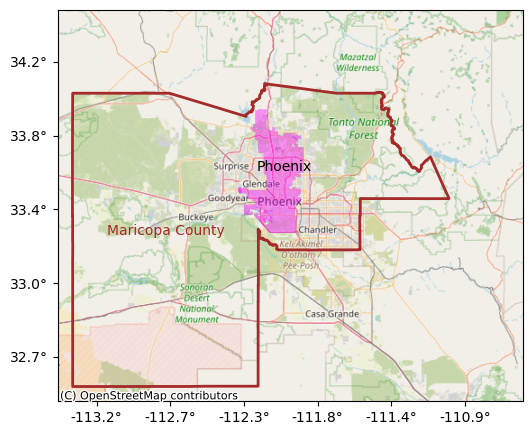

In [62]:
fig, ax = plt.subplots(figsize=(6,6))

#county boundaries
county3857.boundary.plot(ax=ax, color="brown", linewidth=2)

#city boundaries
phoenix3857.boundary.plot(ax=ax,facecolor="magenta",alpha = 0.4, linewidth=0.1)

#river flowlines
salt3857.plot(ax=ax,alpha=0)
verde3857.plot(ax=ax, alpha=0)
#placing labels
ax.annotate(text="Phoenix", 
            xy=(phoenix_name_coords.geometry.x.iloc[0], phoenix_name_coords.geometry.y.iloc[0]),
                horizontalalignment='center', fontsize=10, color='black')
ax.annotate(text="Maricopa County", 
            xy=(maricopa_name_coords.geometry.x.iloc[0], maricopa_name_coords.geometry.y.iloc[0]),
                horizontalalignment='center', fontsize=10, color='brown')

#basemap
ctx.add_basemap(ax,
    source=ctx.providers.OpenStreetMap.Mapnik)

#tranforming axes to lat/lon
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lat_formatter))

#map boundaries
ax.set_xlim(xmin-pad/5, xmax+pad)
ax.set_ylim(ymin-pad/5, ymax+pad)

plt.savefig("../Output/Map_Phoenix_Maricopa.png", dpi = 300, bbox_inches = "tight")
plt.show()

Map 2: City and county boundaries with rivers

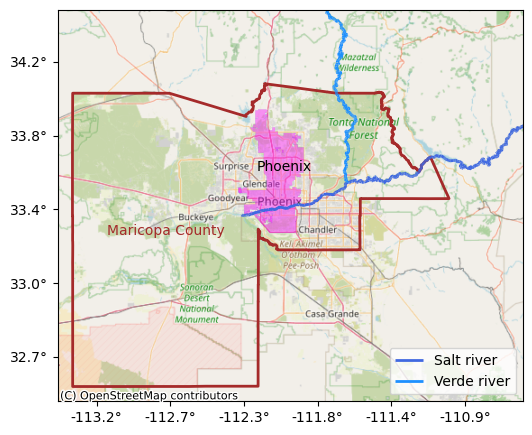

In [63]:
fig, ax = plt.subplots(figsize=(6,6))

#county boundaries
county3857.boundary.plot(ax=ax, color="brown", linewidth=2)

#city boundaries
phoenix3857.boundary.plot(ax=ax,facecolor="magenta",alpha = 0.4, linewidth=0.1)

#river flowlines
salt3857.plot(ax=ax,linewidth=2, color = "royalblue", label = "Salt river")
verde3857.plot(ax=ax, linewidth=2, color ="dodgerblue", label = "Verde river")

#placing labels
ax.annotate(text="Phoenix", 
            xy=(phoenix_name_coords.geometry.x.iloc[0], phoenix_name_coords.geometry.y.iloc[0]),
                horizontalalignment='center', fontsize=10, color='black')
ax.annotate(text="Maricopa County", 
            xy=(maricopa_name_coords.geometry.x.iloc[0], maricopa_name_coords.geometry.y.iloc[0]),
                horizontalalignment='center', fontsize=10, color='brown')

#basemap
ctx.add_basemap(ax,
    source=ctx.providers.OpenStreetMap.Mapnik)

#tranforming axes to lat/lon
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lat_formatter))

#map boundaries
ax.set_xlim(xmin-pad/5, xmax+pad)
ax.set_ylim(ymin-pad/5, ymax+pad)

ax.legend(loc="lower right")
plt.savefig("../Output/Map_Phoenix_Maricopa_Rivers.png", dpi = 300, bbox_inches = "tight")
plt.show()

Map 3: city and county boundaries, rivers, and water gage locations

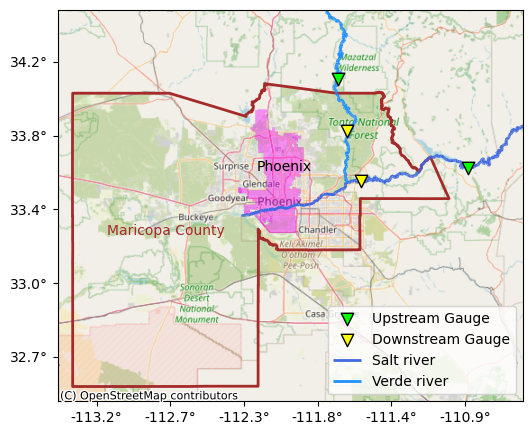

In [64]:
upstream = gages3857[gages3857["UpOrDown"] == "upstream"]
downstream =  gages3857[gages3857["UpOrDown"] == "downstream"]

fig, ax = plt.subplots(figsize=(6,6))

#county boundaries
county3857.boundary.plot(ax=ax, color="brown", linewidth=2)

#city boundaries
phoenix3857.boundary.plot(ax=ax,facecolor="magenta",alpha = 0.4, linewidth=0.1)

#river gages
upstream.plot(ax=ax, edgecolor ="black", color="lime",
    markersize=80,   marker="v",     label="Upstream Gauge", zorder = 10)
downstream.plot(ax=ax, edgecolor ="black", color="yellow",
    markersize=80,   marker="v",     label="Downstream Gauge", zorder = 10)

#river flowlines
salt3857.plot(ax=ax,linewidth=2, color = "royalblue", label = "Salt river")
verde3857.plot(ax=ax, linewidth=2, color ="dodgerblue", label = "Verde river")

#placing labels
ax.annotate(text="Phoenix", 
            xy=(phoenix_name_coords.geometry.x.iloc[0], phoenix_name_coords.geometry.y.iloc[0]),
                horizontalalignment='center', fontsize=10, color='black')
ax.annotate(text="Maricopa County", 
            xy=(maricopa_name_coords.geometry.x.iloc[0], maricopa_name_coords.geometry.y.iloc[0]),
                horizontalalignment='center', fontsize=10, color='brown')

#basemap
ctx.add_basemap(ax,
    source=ctx.providers.OpenStreetMap.Mapnik)

#tranforming axes to lat/lon
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lat_formatter))

#map boundaries
ax.set_xlim(xmin-pad/5, xmax+pad)
ax.set_ylim(ymin-pad/5, ymax+pad)

ax.legend(loc="lower right")

plt.savefig("../Output/Map_Phoenix_Maricopa_Rivers_Gauges.png", dpi = 300, bbox_inches = "tight")
plt.show()

#### Oberved trends in river flow and change in reservoir water levels

In [65]:
historic_data["Time"] = pd.to_datetime(historic_data.Time)
historic_data = historic_data[historic_data.Time>"01-01-1940"]

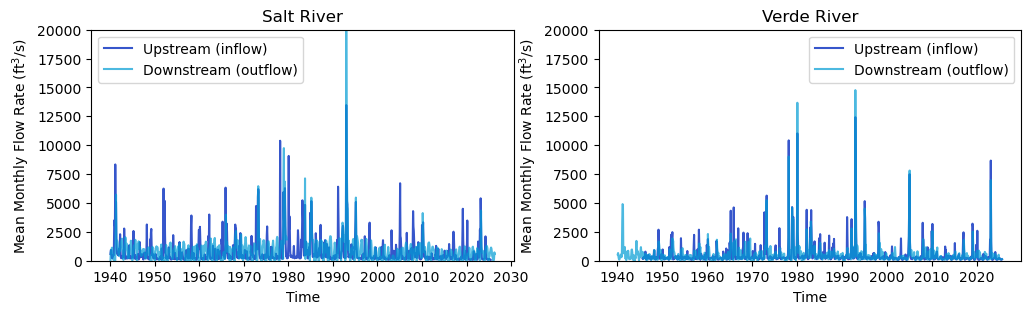

In [66]:
fig, ax = plt.subplots(1,2, figsize = (12,3))

ax[0].plot(historic_data.Time, historic_data.flow_salt_upstream,
           color="#042CBF", label="Upstream (inflow)", alpha = 0.8)
ax[0].plot(historic_data.Time, historic_data.flow_salt_downstream, 
           color ="#009cd4", label="Downstream (outflow)",  alpha= 0.7)
ax[0].set_title("Salt River")
ax[0].legend()
ax[0].set_ylabel("Mean Monthly Flow Rate (ft$^3$/s)")
ax[0].set_xlabel("Time")
ax[0].set_ylim(0, 20000)

ax[1].plot(historic_data.Time, historic_data.flow_verde_upstream,
            color = "#042CBF", label="Upstream (inflow)", alpha= 0.8)
ax[1].plot(historic_data.Time, historic_data.flow_verde_downstream, 
            color = "#009cd4", label="Downstream (outflow)", alpha= 0.7)
ax[1].set_title("Verde River")
ax[1].legend()
ax[1].set_ylabel("Mean Monthly Flow Rate (ft$^3$/s)")
ax[1].set_xlabel("Time")
ax[1].set_ylim(0, 20000)

plt.savefig("../Output/HistoricFlowRates.png", dpi = 300, bbox_inches = "tight")
plt.show()

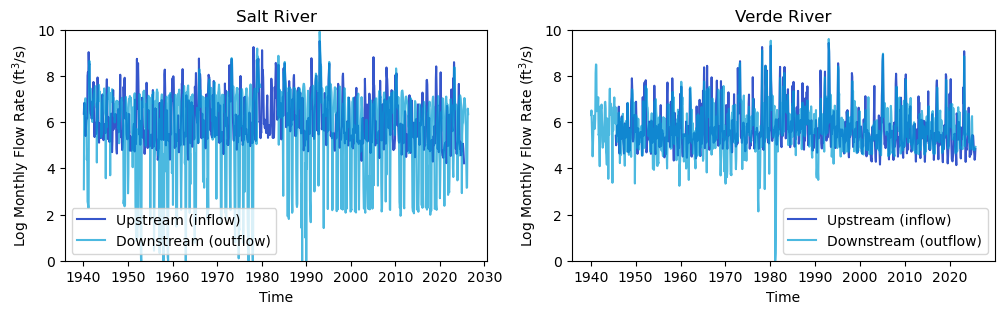

In [67]:
fig, ax = plt.subplots(1,2, figsize = (12,3))

ax[0].plot(historic_data.Time, historic_data.log_flow_salt_upstream,
           color="#042CBF", label="Upstream (inflow)", alpha = 0.8)
ax[0].plot(historic_data.Time, historic_data.log_flow_salt_downstream, 
           color ="#009cd4", label="Downstream (outflow)",  alpha= 0.7)
ax[0].set_title("Salt River")
ax[0].legend()
ax[0].set_ylabel("Log Monthly Flow Rate (ft$^3$/s)")
ax[0].set_xlabel("Time")
ax[0].set_ylim(0, 10)

ax[1].plot(historic_data.Time, historic_data.log_flow_verde_upstream,
            color = "#042CBF", label="Upstream (inflow)", alpha= 0.8)
ax[1].plot(historic_data.Time, historic_data.log_flow_verde_downstream, 
            color = "#009cd4", label="Downstream (outflow)", alpha= 0.7)
ax[1].set_title("Verde River")
ax[1].legend()
ax[1].set_ylabel("Log Monthly Flow Rate (ft$^3$/s)")
ax[1].set_xlabel("Time")
ax[1].set_ylim(0, 10)
plt.savefig("../Output/HistoricLogFlowRates.png", dpi = 300, bbox_inches = "tight")
plt.show()

Estimating change in reservoir water levels by taking the cumulative difference between upstream and downstream flow, and then plotting 

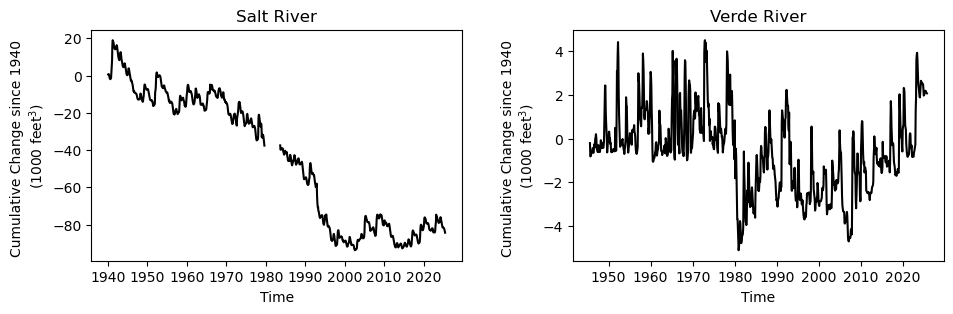

In [68]:
#calculating difference between upstream and downstream flow
historic_data["Diff_Verde"] = historic_data.flow_verde_upstream - historic_data.flow_verde_downstream
historic_data["Diff_Salt"] = historic_data.flow_salt_upstream - historic_data.flow_salt_downstream

#taking cumulative sum 
historic_data["CumDiff_Verde"] = historic_data.Diff_Verde.cumsum()
historic_data["CumDiff_Salt"] = historic_data.Diff_Salt.cumsum()

#plotting
fig, ax = plt.subplots(1,2, figsize =(11,3))
plt.subplots_adjust( wspace=0.3)  

ax[0].plot(historic_data.Time, historic_data.CumDiff_Salt/1000, color ="black")
ax[0].set_title("Salt River")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Cumulative Change since 1940 \n(1000 feet$^3$)")

ax[1].plot(historic_data.Time, historic_data.CumDiff_Verde/1000, color ="black")
ax[1].set_title("Verde River")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Cumulative Change since 1940 \n(1000 feet$^3$)")

plt.savefig("../Output/Historic_CumulativeChangeinFlow.png", dpi = 300, bbox_inches = "tight")
plt.show()

#### Observed and future trends in river flow and reservoir water levels

Plotting oberved and future predicted log flow rates for Verde river

In [69]:
PredictedVals_Verde_ssp245["Time"] = pd.to_datetime(PredictedVals_Verde_ssp245.Time)
PredictedVals_Verde_ssp585["Time"] = pd.to_datetime(PredictedVals_Verde_ssp585.Time)

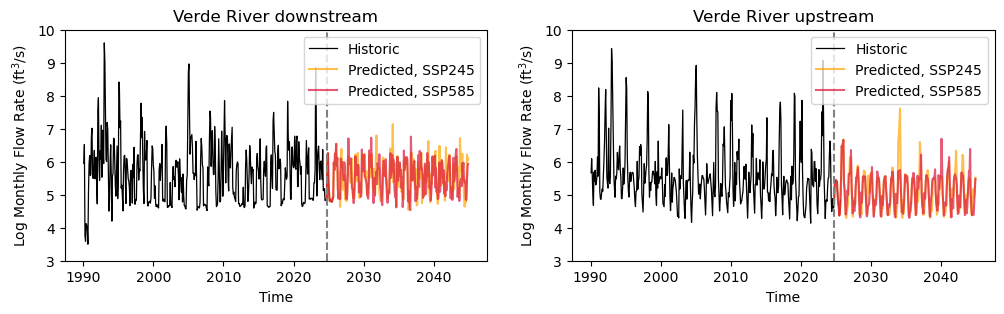

In [70]:
#Verde river
fig, ax = plt.subplots(1,2, figsize = (12,3))

ax[0].plot(historic_data[historic_data.Time>"01-01-1990"].Time, 
           historic_data[historic_data.Time>"01-01-1990"].log_flow_verde_downstream,
           color="black", label="Historic" , linewidth = 0.9)
ax[0].plot(PredictedVals_Verde_ssp245.Time, PredictedVals_Verde_ssp245.log_flow_verde_downstream, 
           color ="orange", label="Predicted, SSP245", alpha=0.7)
ax[0].plot(PredictedVals_Verde_ssp585.Time, PredictedVals_Verde_ssp585.log_flow_verde_downstream, 
           color ="crimson", label="Predicted, SSP585", alpha= 0.7)
ax[0].set_title("Verde River downstream")
ax[0].legend()
ax[0].set_ylabel("Log Monthly Flow Rate (ft$^3$/s)")
ax[0].set_xlabel("Time")
ax[0].set_ylim(3, 10)
ax[0].axvline(PredictedVals_Verde_ssp245.Time.iloc[0], linestyle ="--", color = "grey")

ax[1].plot(historic_data[historic_data.Time>"01-01-1990"].Time, 
           historic_data[historic_data.Time>"01-01-1990"].log_flow_verde_upstream,
           color="black", label="Historic" , linewidth = 0.9)
ax[1].plot(PredictedVals_Verde_ssp245.Time, PredictedVals_Verde_ssp245.log_flow_verde_upstream, 
           color ="orange", label="Predicted, SSP245", alpha=0.7)
ax[1].plot(PredictedVals_Verde_ssp585.Time, PredictedVals_Verde_ssp585.log_flow_verde_upstream, 
           color ="crimson", label="Predicted, SSP585", alpha=0.7)
ax[1].set_title("Verde River upstream")
ax[1].legend()
ax[1].set_ylabel("Log Monthly Flow Rate (ft$^3$/s)")
ax[1].set_xlabel("Time")
ax[1].set_ylim(3, 10)
ax[1].axvline(PredictedVals_Verde_ssp245.Time.iloc[0], linestyle ="--", color = "grey")

plt.savefig("../Output/HistoricAndFuture_LogFlow_Verde.png", dpi = 300, bbox_inches = "tight")

plt.show()

Plotting observed and future predicted flow rates for Salt River

In [71]:
PredictedVals_Salt_ssp245["Time"] = pd.to_datetime(PredictedVals_Salt_ssp245.Time)
PredictedVals_Salt_ssp585["Time"] = pd.to_datetime(PredictedVals_Salt_ssp585.Time)

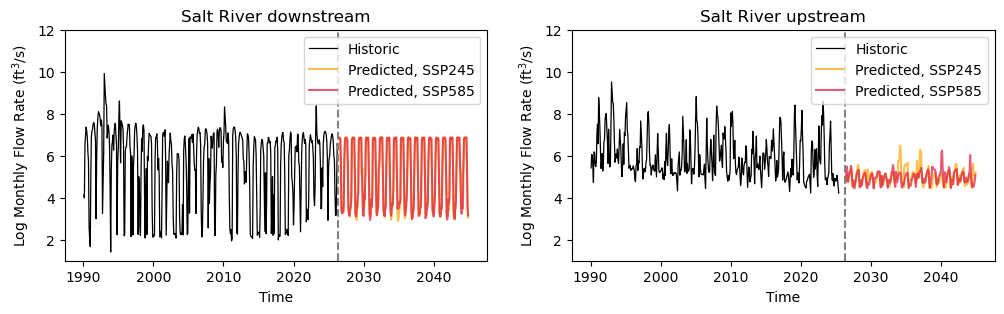

In [72]:
#Verde river
fig, ax = plt.subplots(1,2, figsize = (12,3))

ax[0].plot(historic_data[historic_data.Time>"01-01-1990"].Time, 
           historic_data[historic_data.Time>"01-01-1990"].log_flow_salt_downstream,
           color="black", label="Historic" , linewidth = 0.9)
ax[0].plot(PredictedVals_Salt_ssp245.Time, PredictedVals_Salt_ssp245.log_flow_salt_downstream, 
           color ="orange", label="Predicted, SSP245", alpha=0.7)
ax[0].plot(PredictedVals_Salt_ssp585.Time, PredictedVals_Salt_ssp585.log_flow_salt_downstream, 
           color ="crimson", label="Predicted, SSP585", alpha= 0.7)
ax[0].set_title("Salt River downstream")
ax[0].legend()
ax[0].set_ylabel("Log Monthly Flow Rate (ft$^3$/s)")
ax[0].set_xlabel("Time")
ax[0].set_ylim(1, 12)
ax[0].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "grey")

ax[1].plot(historic_data[historic_data.Time>"01-01-1990"].Time, 
           historic_data[historic_data.Time>"01-01-1990"].log_flow_salt_upstream,
           color="black", label="Historic" , linewidth = 0.9)
ax[1].plot(PredictedVals_Salt_ssp245.Time, PredictedVals_Salt_ssp245.log_flow_salt_upstream, 
           color ="orange", label="Predicted, SSP245", alpha=0.7)
ax[1].plot(PredictedVals_Salt_ssp585.Time, PredictedVals_Salt_ssp585.log_flow_salt_upstream, 
           color ="crimson", label="Predicted, SSP585", alpha=0.7)
ax[1].set_title("Salt River upstream")
ax[1].legend()
ax[1].set_ylabel("Log Monthly Flow Rate (ft$^3$/s)")
ax[1].set_xlabel("Time")
ax[1].set_ylim(1, 12)
ax[1].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "grey")

plt.savefig("../Output/HistoricAndFuture_LogFlow_Salt.png", dpi = 300, bbox_inches = "tight")

plt.show()

Plotting cumulative change in water levels for Verde river

In [73]:
#current water level (relative to Jan 1940)
#(estimated from cumulative difference b/w inflow and outflow)
current_level_verde = historic_data[historic_data.Time == PredictedVals_Verde_ssp245.Time[0]].CumDiff_Verde

#adding current water level to future predicted cumulative change
PredictedVals_Verde_ssp245["CumDiff_flow2"] = PredictedVals_Verde_ssp245.CumDiff_flow.apply(lambda x: x+current_level_verde)
PredictedVals_Verde_ssp585["CumDiff_flow2"] = PredictedVals_Verde_ssp585.CumDiff_flow.apply(lambda x: x+current_level_verde)

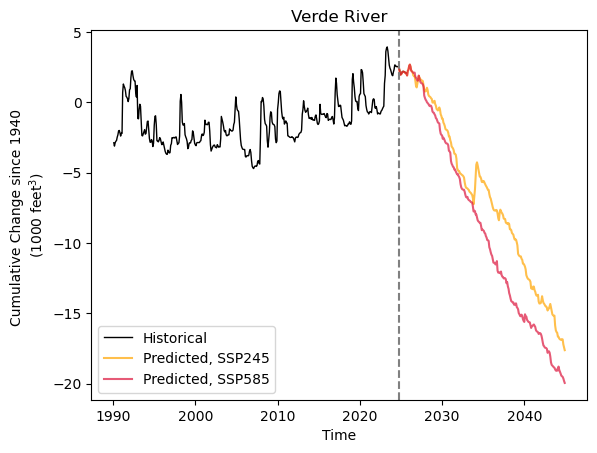

In [ ]:
plt.plot(historic_data[historic_data.Time>"01-01-1990"].Time, 
         historic_data[historic_data.Time>"01-01-1990"].CumDiff_Verde/1000, 
         color ="black", linewidth = 1, label ="Historical")
plt.plot(PredictedVals_Verde_ssp245.Time, PredictedVals_Verde_ssp245.CumDiff_flow2/1000, 
         color ="orange", alpha = 0.7, label = "Predicted, SSP245")
plt.plot(PredictedVals_Verde_ssp585.Time, PredictedVals_Verde_ssp585.CumDiff_flow2/1000, 
         color ="crimson", alpha=0.7,label = "Predicted, SSP585")
plt.title("Verde River")
plt.xlabel("Time")
plt.ylabel("Cumulative Change since 1940 \n(1000 feet$^3$)")
plt.axvline(PredictedVals_Verde_ssp585.Time.iloc[0], linestyle ="--", color = "grey")
plt.legend()

plt.savefig("../Output/HistoricAndFuture_CumulativeChange_Verde.png", dpi = 300, bbox_inches = "tight")

plt.show()

Plotting cumulative change in water levels for Salt river

In [75]:
#current water level (relative to Jan 1940)
#(estimated from cumulative difference b/w inflow and outflow)
current_level_salt = historic_data.CumDiff_Salt.dropna().tail(1)

#adding current water level to future predicted cumulative change
PredictedVals_Salt_ssp245["CumDiff_flow2"] = PredictedVals_Salt_ssp245.CumDiff_flow.apply(lambda x: x+current_level_salt)
PredictedVals_Salt_ssp585["CumDiff_flow2"] = PredictedVals_Salt_ssp585.CumDiff_flow.apply(lambda x: x+current_level_salt)

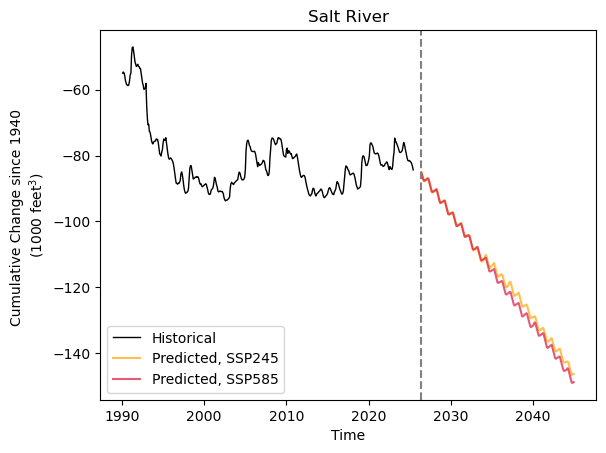

In [ ]:
plt.plot(historic_data[historic_data.Time>"01-01-1990"].Time, 
         historic_data[historic_data.Time>"01-01-1990"].CumDiff_Salt/1000, 
         color ="black", linewidth = 1, label ="Historical")
plt.plot(PredictedVals_Salt_ssp245.Time, PredictedVals_Salt_ssp245.CumDiff_flow2/1000, 
         color ="orange", alpha = 0.7, label = "Predicted, SSP245")
plt.plot(PredictedVals_Salt_ssp585.Time, PredictedVals_Salt_ssp585.CumDiff_flow2/1000, 
         color ="crimson", alpha=0.7,label = "Predicted, SSP585")
plt.axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "grey")
plt.title("Salt River")
plt.xlabel("Time")
plt.ylabel("Cumulative Change since 1940 \n(1000 feet$^3$)")

plt.legend()
plt.savefig("../Output/HistoricAndFuture_CumulativeChange_Salt.png", dpi = 300, bbox_inches = "tight")

plt.show()

#### Observed and future temporal trends in features

Human population

In [77]:
futurevals_features_ssp245["Time"] = pd.to_datetime(futurevals_features_ssp245.Time)
futurevals_features_ssp585["Time"] = pd.to_datetime(futurevals_features_ssp585.Time)

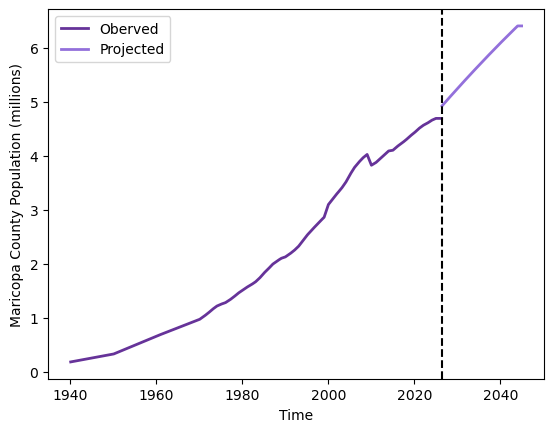

In [78]:
plt.plot(historic_data.Time, historic_data.Population/10**6, 
         color = "rebeccapurple", label ="Oberved", linewidth=2)
plt.plot(futurevals_features_ssp245.Time, futurevals_features_ssp245.Population/10**6, 
         color = "mediumpurple", label = "Projected", linewidth = 2)
plt.axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
plt.xlabel("Time")
plt.ylabel("Maricopa County Population (millions)")
plt.legend()

plt.savefig("../Output/HistoricAndFuture_Population_Maricopa.png", dpi = 300, bbox_inches = "tight")

plt.show()

Data centers

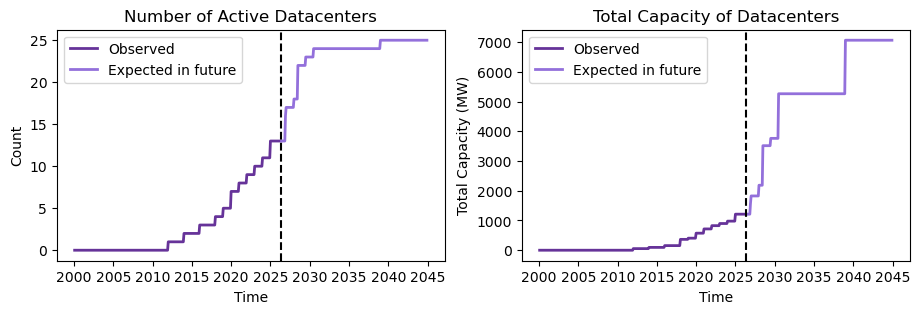

In [79]:
fig, ax = plt.subplots(1,2, figsize = (11,3))
ax[0].plot(historic_data[historic_data.Time>"01-01-2000"].Time, 
         historic_data[historic_data.Time>"01-01-2000"].datacenters_TotalNum, 
         color = "rebeccapurple", label ="Observed", linewidth=2)
ax[0].plot(futurevals_features_ssp245.Time, futurevals_features_ssp245.datacenters_TotalNum, 
         color = "mediumpurple", label = "Expected in future", linewidth = 2)
ax[0].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Count")
ax[0].set_title("Number of Active Datacenters")
ax[0].legend()

ax[1].plot(historic_data[historic_data.Time>"01-01-2000"].Time, 
         historic_data[historic_data.Time>"01-01-2000"].datacenters_TotalMW, 
         color = "rebeccapurple", label ="Observed", linewidth=2)
ax[1].plot(futurevals_features_ssp245.Time, futurevals_features_ssp245.datacenters_TotalMW, 
         color = "mediumpurple", label = "Expected in future", linewidth = 2)
ax[1].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Total Capacity (MW)")
ax[1].set_title("Total Capacity of Datacenters")
ax[1].legend()

plt.savefig("../Output/HistoricAndFuture_Datacenters_Maricopa.png", dpi = 300, bbox_inches = "tight")

plt.show()

Irrigated acres (historical data only)

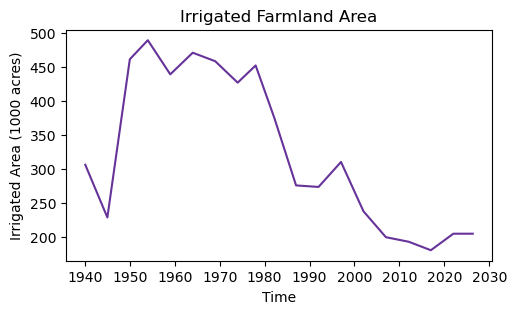

In [80]:
plt.figure(figsize=(5.5,3))
plt.plot(historic_data.Time, 
         historic_data.IrrigatedLand_Acres/1000,
         color = "rebeccapurple")
plt.title("Irrigated Farmland Area")
plt.xlabel("Time")
plt.ylabel("Irrigated Area (1000 acres)")

plt.savefig("../Output/IrrigatedAcres.png", dpi = 300, bbox_inches = "tight")

plt.show()

Climate - only plotting climate in Salt river watershed as an example

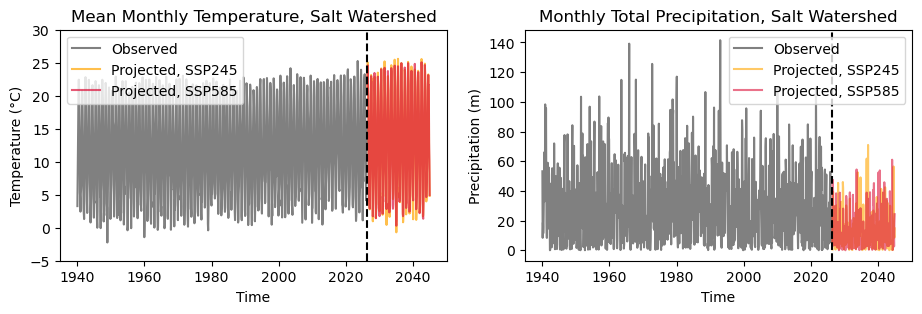

In [81]:
fig, ax = plt.subplots(1,2, figsize = (11,3))
ax[0].plot(historic_data.Time, 
         historic_data.Temp_Salt, 
         color = "grey", label ="Observed")
ax[0].plot(futurevals_features_ssp245.Time, futurevals_features_ssp245.Temp_Salt, 
         color = "orange", label = "Projected, SSP245", alpha = 0.7)
ax[0].plot(futurevals_features_ssp585.Time, futurevals_features_ssp585.Temp_Salt, 
         color = "crimson", label = "Projected, SSP585", alpha = 0.7)
ax[0].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Temperature (°C)")
ax[0].set_title("Mean Monthly Temperature, Salt Watershed")
ax[0].set_ylim(-5,30)
ax[0].legend()

ax[1].plot(historic_data.Time, 
         historic_data.Precip_Salt/1000, 
         color = "grey", label ="Observed")
ax[1].plot(futurevals_features_ssp245.Time, futurevals_features_ssp245.Precip_Salt/1000, 
         color = "orange", label = "Projected, SSP245", alpha=0.6)
ax[1].plot(futurevals_features_ssp585.Time, futurevals_features_ssp585.Precip_Salt/1000, 
         color = "crimson", label = "Projected, SSP585", alpha=0.6)
ax[1].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Precipitation (m)")
ax[1].set_title("Monthly Total Precipitation, Salt Watershed")
ax[1].legend()

plt.savefig("../Output/HistoricAndFuture_Climate_Salt.png", dpi = 300, bbox_inches = "tight")

plt.show()

Rescaling climate data to annual timescales

In [82]:
historic_data.set_index("Time", drop=False, inplace=True)
climate_historic_annual = historic_data.resample("YS").agg({
    "Temp_Salt":"mean", 
    "Temp_Verde":"mean", 
    "Precip_Salt":"sum",
    "Precip_Verde":"sum"})

futurevals_features_ssp245.set_index("Time", drop=False, inplace=True)
climate_ssp245_annual = futurevals_features_ssp245.resample("YS").agg({
    "Temp_Salt":"mean", 
    "Temp_Verde":"mean", 
    "Precip_Salt":"sum",
    "Precip_Verde":"sum"})
futurevals_features_ssp585.set_index("Time", drop=False, inplace=True)
climate_ssp585_annual = futurevals_features_ssp585.resample("YS").agg({
    "Temp_Salt":"mean", 
    "Temp_Verde":"mean", 
    "Precip_Salt":"sum",
    "Precip_Verde":"sum"})

Plotting watershed climate at annual timescales

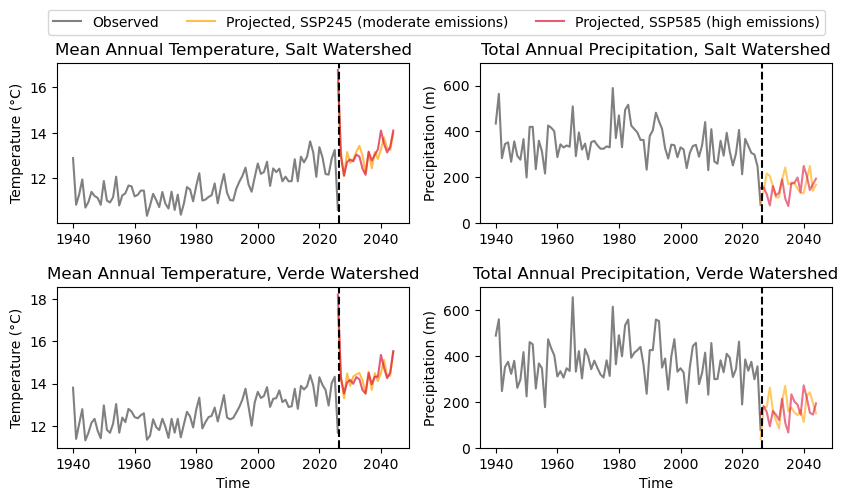

In [83]:
fig, ax = plt.subplots(2,2, figsize = (10,5))
plt.subplots_adjust( hspace=0.4)  

ax[0,0].plot( climate_historic_annual.Temp_Salt, 
         color = "grey", label ="Observed")
ax[0,0].plot(climate_ssp245_annual.Temp_Salt, 
         color = "orange", label = "Projected, SSP245 (moderate emissions)", alpha = 0.7)
ax[0,0].plot(climate_ssp585_annual.Temp_Salt, 
         color = "crimson", label = "Projected, SSP585 (high emissions)", alpha = 0.7)
ax[0,0].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[0,0].set_ylabel("Temperature (°C)")
ax[0,0].set_title("Mean Annual Temperature, Salt Watershed")

ax[0,1].plot( climate_historic_annual.Precip_Salt/1000, 
         color = "grey")
ax[0,1].plot( climate_ssp245_annual.Precip_Salt/1000, 
         color = "orange", alpha=0.6)
ax[0,1].plot(climate_ssp585_annual.Precip_Salt/1000, 
         color = "crimson",alpha=0.6)
ax[0,1].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[0,1].set_ylabel("Precipitation (m)")
ax[0,1].set_title("Total Annual Precipitation, Salt Watershed")
ax[0,1].set_ylim(0,700)

ax[1,0].plot( climate_historic_annual.Temp_Verde, 
         color = "grey",)
ax[1,0].plot(climate_ssp245_annual.Temp_Verde, 
         color = "orange", alpha = 0.7)
ax[1,0].plot(climate_ssp585_annual.Temp_Verde, 
         color = "crimson",alpha = 0.7)
ax[1,0].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[1,0].set_ylabel("Temperature (°C)")
ax[1,0].set_title("Mean Annual Temperature, Verde Watershed")
ax[1,0].set_xlabel("Time")

ax[1,1].plot( climate_historic_annual.Precip_Verde/1000, 
         color = "grey")
ax[1,1].plot( climate_ssp245_annual.Precip_Verde/1000, 
         color = "orange", alpha=0.6)
ax[1,1].plot(climate_ssp585_annual.Precip_Verde/1000, 
         color = "crimson", alpha=0.6)
ax[1,1].axvline(historic_data.Time.iloc[-1], linestyle ="--", color = "black")
ax[1,1].set_ylabel("Precipitation (m)")
ax[1,1].set_title("Total Annual Precipitation, Verde Watershed")
ax[1,1].set_ylim(0,700)
ax[1,1].set_xlabel("Time")

fig.legend( bbox_to_anchor=(0.9, 1), ncol=3)

plt.savefig("../Output/HistoricAndFuture_Climate_Annual.png", dpi = 300, bbox_inches = "tight")

plt.show()